# 02 — Terrain Derivatives (Stage C)

Reads `data/derivatives/dem_1m.tif` and writes the rasters the pad detector needs, per `docs/05_processing_pipeline.md` § C.

**Outputs:**
- `slope.tif`           — WhiteboxTools `Slope` (Horn 1981)
- `roughness_11.tif`    — σ of elevation in 11×11 window (Python)
- `local_relief_10.tif` — max − min of elevation in 10 m disk (Python)
- `tpi_05.tif`, `tpi_15.tif`, `tpi_51.tif` — classic TPI, circular kernels (Python)
- `tpi_grad_mag.tif`, `tpi_grad_dir.tif` — gradient of `tpi_15`

In [1]:
from pathlib import Path
import numpy as np
import rasterio
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from datetime import datetime

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DERIV = PROJECT / 'data' / 'derivatives'
LOGS  = PROJECT / 'docs'
DEM_PATH = DERIV / 'dem_1m.tif'
assert DEM_PATH.exists(), f'Run 01_preprocessing first — missing {DEM_PATH}'

with rasterio.open(DEM_PATH) as ds:
    dem = ds.read(1).astype(np.float32)
    transform = ds.transform
    crs = ds.crs
    nodata = ds.nodata
cellsize = float(transform.a)
H, W = dem.shape
if nodata is not None:
    dem = np.where(dem == nodata, np.nan, dem)
nan_frac = float(np.isnan(dem).mean())
print(f'DEM {H}x{W} @ {cellsize} m, NaN {100*nan_frac:.3f}%, CRS {crs.to_string()[:55]}...')

def write_tif(path, arr, dtype='float32', nodata_val=-9999.0):
    a = arr.astype(dtype)
    if dtype == 'float32':
        a = np.where(np.isnan(a), nodata_val, a).astype('float32')
    with rasterio.open(
        path, 'w', driver='GTiff', height=a.shape[0], width=a.shape[1], count=1,
        dtype=dtype, crs=crs, transform=transform, nodata=nodata_val,
        tiled=True, compress='deflate', predictor=3 if dtype=='float32' else 2,
    ) as ds:
        ds.write(a, 1)
    print('wrote', path.name)

DEM 1500x1500 @ 1.0 m, NaN 0.000%, CRS COMPD_CS["NAD83(2011) / UTM zone 17N + NAVD88 height - ...


## 1. Slope — WhiteboxTools `Slope` (Horn 1981)

In [2]:
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(str(DERIV))
wbt.set_verbose_mode(False)

SLOPE_PATH = DERIV / 'slope.tif'
rc = wbt.slope(dem=str(DEM_PATH), output=str(SLOPE_PATH), units='degrees')
print('wbt.slope rc =', rc)

with rasterio.open(SLOPE_PATH) as ds:
    slope = ds.read(1).astype(np.float32)
    sn = ds.nodata
if sn is not None:
    slope = np.where(slope == sn, np.nan, slope)
print(f'slope (deg) p50={np.nanpercentile(slope,50):.2f}  p95={np.nanpercentile(slope,95):.2f}')

wbt.slope rc = 0
slope (deg) p50=8.00  p95=22.49


## Python helpers — NaN-safe disk mean / generic stats

In [3]:
def disk_kernel(radius_cells):
    r = int(round(radius_cells))
    y, x = np.ogrid[-r:r+1, -r:r+1]
    return (x*x + y*y) <= r*r

def nanmean_filter(arr, kernel):
    valid = np.isfinite(arr).astype(np.float32)
    a0 = np.where(valid.astype(bool), arr, 0).astype(np.float32)
    kf = kernel.astype(np.float32)
    s = ndi.convolve(a0, kf, mode='nearest')
    c = ndi.convolve(valid, kf, mode='nearest')
    out = np.full_like(arr, np.nan, dtype=np.float32)
    np.divide(s, c, out=out, where=c > 0)
    return out

def nanmax_filter_disk(arr, kernel):
    big = np.where(np.isfinite(arr), arr, -np.inf)
    return np.where(np.isfinite(ndi.maximum_filter(big, footprint=kernel, mode='nearest')),
                    ndi.maximum_filter(big, footprint=kernel, mode='nearest'),
                    np.nan).astype(np.float32)

def nanmin_filter_disk(arr, kernel):
    small = np.where(np.isfinite(arr), arr, np.inf)
    r = ndi.minimum_filter(small, footprint=kernel, mode='nearest')
    return np.where(np.isfinite(r), r, np.nan).astype(np.float32)

## 2. Roughness — σ(elevation) in an 11 × 11 window

In [4]:
WIN = 11
k = np.ones((WIN, WIN), dtype=np.float32)
valid = np.isfinite(dem).astype(np.float32)
z0 = np.where(valid.astype(bool), dem, 0).astype(np.float32)
s  = ndi.convolve(z0,         k, mode='nearest')
s2 = ndi.convolve(z0 * z0,    k, mode='nearest')
n  = ndi.convolve(valid,      k, mode='nearest')
var = np.where(n > 1, (s2 - s * s / np.maximum(n, 1)) / np.maximum(n - 1, 1), np.nan)
roughness = np.sqrt(np.clip(var, 0, None)).astype(np.float32)
roughness[n < (WIN * WIN)] = np.nan
print(f'roughness_{WIN}: p50={np.nanpercentile(roughness,50):.3f} p95={np.nanpercentile(roughness,95):.3f} m')
print(f'  cells with roughness<0.15 m: {100*np.nansum(roughness<0.15)/np.isfinite(roughness).sum():.2f}%')
write_tif(DERIV / f'roughness_{WIN}.tif', roughness)

roughness_11: p50=0.447 p95=1.133 m
  cells with roughness<0.15 m: 8.81%


wrote roughness_11.tif


## 3. Local relief — `max − min` in a 10 m disk

In [5]:
rk = disk_kernel(10 / cellsize)
zmax = nanmax_filter_disk(dem, rk)
zmin = nanmin_filter_disk(dem, rk)
local_relief = (zmax - zmin).astype(np.float32)
print(f'local_relief_10: p50={np.nanpercentile(local_relief,50):.2f} m p95={np.nanpercentile(local_relief,95):.2f} m')
write_tif(DERIV / 'local_relief_10.tif', local_relief)

local_relief_10: p50=2.80 m p95=6.69 m


wrote local_relief_10.tif


## 4. TPI at 5 / 15 / 51 m (circular kernels)

In [6]:
def tpi(z, radius_m):
    return (z - nanmean_filter(z, disk_kernel(radius_m / cellsize))).astype(np.float32)

tpi_05 = tpi(dem,  5.0)
tpi_15 = tpi(dem, 15.0)
tpi_51 = tpi(dem, 25.5)  # diameter 51 m -> radius 25.5
for name, arr in [('tpi_05', tpi_05), ('tpi_15', tpi_15), ('tpi_51', tpi_51)]:
    print(f'{name} p5={np.nanpercentile(arr,5):+.3f} p50={np.nanpercentile(arr,50):+.3f} p95={np.nanpercentile(arr,95):+.3f}')
    write_tif(DERIV / f'{name}.tif', arr)

tpi_05 p5=-0.210 p50=-0.002 p95=+0.214


wrote tpi_05.tif
tpi_15 p5=-0.523 p50=+0.010 p95=+0.477


wrote tpi_15.tif
tpi_51 p5=-0.845 p50=+0.022 p95=+0.761


wrote tpi_51.tif


## 5. TPI gradient (magnitude + compass direction) — pad-scale asymmetry

In [7]:
gy, gx = np.gradient(tpi_15, cellsize)  # axis 0 = rows (north-south, flipped)
tpi_grad_mag = np.hypot(gx, gy).astype(np.float32)
# compass bearing toward positive TPI side (i.e. toward the fill, away from the cut)
tpi_grad_dir = (np.degrees(np.arctan2(gx, -gy)) % 360).astype(np.float32)
print(f'tpi_grad_mag p50={np.nanpercentile(tpi_grad_mag,50):.4f} p95={np.nanpercentile(tpi_grad_mag,95):.4f}')
write_tif(DERIV / 'tpi_grad_mag.tif', tpi_grad_mag)
write_tif(DERIV / 'tpi_grad_dir.tif', tpi_grad_dir)

tpi_grad_mag p50=0.0497 p95=0.2648


wrote tpi_grad_mag.tif


wrote tpi_grad_dir.tif


## 6. QA — six-panel overview

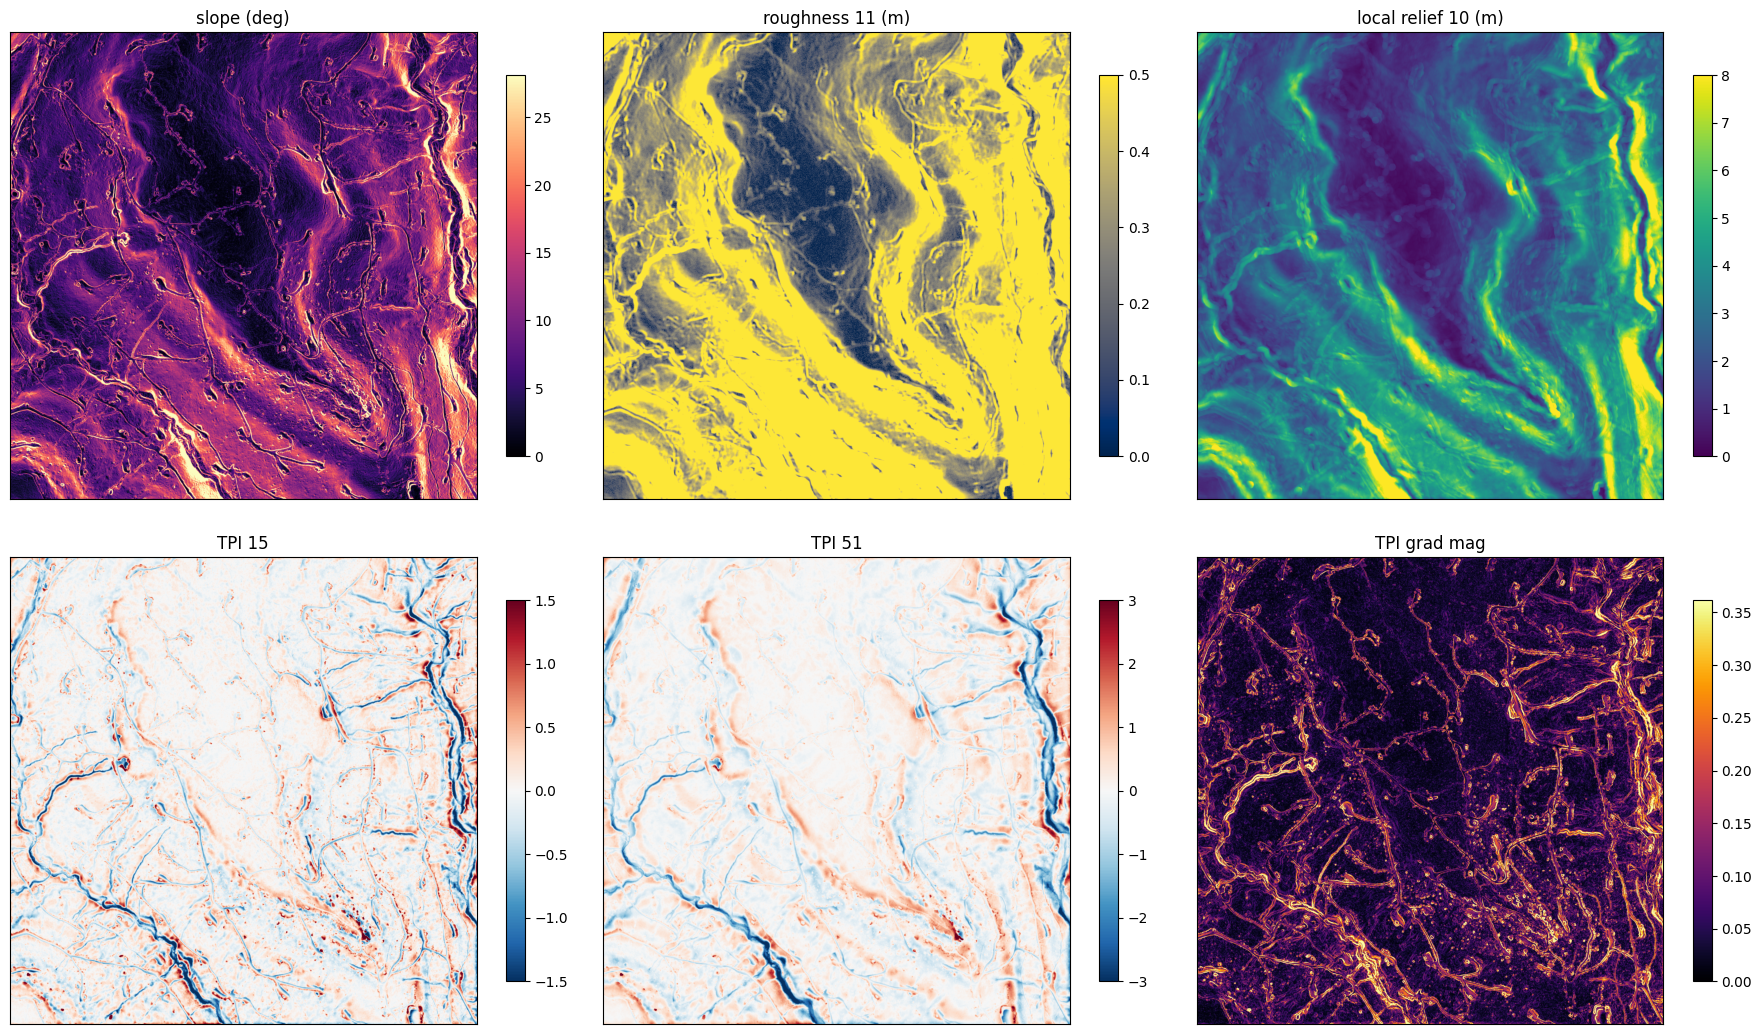

In [8]:
panels = [
    ('slope (deg)',      slope,        'magma',   0,  np.nanpercentile(slope, 98)),
    ('roughness 11 (m)', roughness,    'cividis', 0,  0.5),
    ('local relief 10 (m)', local_relief, 'viridis', 0, np.nanpercentile(local_relief, 98)),
    ('TPI 15',           tpi_15,       'RdBu_r', -1.5, 1.5),
    ('TPI 51',           tpi_51,       'RdBu_r', -3, 3),
    ('TPI grad mag',     tpi_grad_mag, 'inferno', 0, np.nanpercentile(tpi_grad_mag, 98)),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (title, arr, cmap, vmin, vmax) in zip(axes.flat, panels):
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

## 7. Append to analysis log

## 8. Local Relief Model (LRM)

Per *Detecting abandoned roads beneath forest canopy* (Hesse 2010 SLRM).

`LRM_k = z - uniform_filter(z, size=k)` — removes large-scale topographic trend,
isolates micro-topographic anomalies. Single most-diagnostic derivative for
sunken roads and benched trails in forested terrain. Two scales:

- `lrm_25.tif` — kernel 25 cells (captures narrow trails / single-lane)
- `lrm_51.tif` — kernel 51 cells (captures two-lane roads)


In [9]:
from scipy.ndimage import uniform_filter
for k in (25, 51):
    valid = np.isfinite(dem).astype(np.float32)
    z0 = np.where(valid.astype(bool), dem, 0).astype(np.float32)
    sm = uniform_filter(z0, size=k, mode="nearest")
    sc = uniform_filter(valid, size=k, mode="nearest")
    smooth = np.where(sc > 0, sm / sc, np.nan)
    lrm = (dem - smooth).astype(np.float32)
    p50 = np.nanpercentile(lrm, 50); p5 = np.nanpercentile(lrm, 5); p95 = np.nanpercentile(lrm, 95)
    print(f"lrm_{k}: p5={p5:+.2f}  p50={p50:+.2f}  p95={p95:+.2f} m")
    write_tif(DERIV / f"lrm_{k}.tif", lrm)


lrm_25: p5=-0.50  p50=+0.01  p95=+0.46 m


wrote lrm_25.tif
lrm_51: p5=-0.95  p50=+0.03  p95=+0.86 m


wrote lrm_51.tif


## 9. Topographic openness (Yokoyama 2002)

`openness_pos` = mean zenith angle to horizon across 8 directions at radius L.
`openness_neg` = mean nadir angle to anti-horizon. Negative openness highlights
sunken roads, ditches, and drainages in a direction-independent way.

Radius L = 25 cells (25 m) — tuned for forest-road width. Pure-numpy 8-direction scan.


In [10]:
def openness(z, L=25, cellsize=1.0):
    dirs = [(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1),(-1,-1)]
    valid = np.isfinite(z)
    z0 = np.where(valid, z, 0).astype(np.float32)
    phi_sum = np.zeros_like(z, dtype=np.float32)
    psi_sum = np.zeros_like(z, dtype=np.float32)
    for dr, dc in dirs:
        step = cellsize * np.hypot(dr, dc)
        max_tan_up = np.full_like(z, -np.inf, dtype=np.float32)
        min_tan_dn = np.full_like(z,  np.inf, dtype=np.float32)
        for k in range(1, L + 1):
            zs = np.roll(z0, shift=(dr*k, dc*k), axis=(0, 1))
            vs = np.roll(valid, shift=(dr*k, dc*k), axis=(0, 1))
            if dr > 0: vs[:dr*k, :] = False
            elif dr < 0: vs[dr*k:, :] = False
            if dc > 0: vs[:, :dc*k] = False
            elif dc < 0: vs[:, dc*k:] = False
            tan_a = np.where(vs, (zs - z0) / (k * step), np.nan).astype(np.float32)
            np.fmax(max_tan_up, tan_a, out=max_tan_up, where=vs)
            np.fmin(min_tan_dn, tan_a, out=min_tan_dn, where=vs)
        alpha_max = np.arctan(np.where(np.isfinite(max_tan_up), max_tan_up, 0))
        alpha_min = np.arctan(np.where(np.isfinite(min_tan_dn), min_tan_dn, 0))
        phi_sum += (np.pi/2 - alpha_max).astype(np.float32)
        psi_sum += (np.pi/2 + alpha_min).astype(np.float32)
    phi = np.degrees(phi_sum / 8).astype(np.float32)
    psi = np.degrees(psi_sum / 8).astype(np.float32)
    phi[~valid] = np.nan
    psi[~valid] = np.nan
    return phi, psi

print("computing openness (L=25 m)...")
op_pos, op_neg = openness(dem, L=25, cellsize=cellsize)
print(f"openness_pos p50={np.nanpercentile(op_pos,50):.2f} deg")
print(f"openness_neg p50={np.nanpercentile(op_neg,50):.2f} deg")
write_tif(DERIV / "openness_pos.tif", op_pos)
write_tif(DERIV / "openness_neg.tif", op_neg)


computing openness (L=25 m)...


openness_pos p50=88.01 deg
openness_neg p50=88.04 deg


wrote openness_pos.tif


wrote openness_neg.tif


In [11]:
entry = (
    f"\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage C complete (02_derivatives)\n\n"
    f"- slope (WBT): p50={np.nanpercentile(slope,50):.2f} deg, p95={np.nanpercentile(slope,95):.2f} deg\n"
    f"- roughness_11 (sigma elev, 11x11): p50={np.nanpercentile(roughness,50):.3f} m, p95={np.nanpercentile(roughness,95):.3f} m\n"
    f"- local_relief_10 (max-min, 10 m disk): p50={np.nanpercentile(local_relief,50):.2f} m, p95={np.nanpercentile(local_relief,95):.2f} m\n"
    f"- tpi_05 / tpi_15 / tpi_51: p95 mag {np.nanpercentile(np.abs(tpi_05),95):.2f} / {np.nanpercentile(np.abs(tpi_15),95):.2f} / {np.nanpercentile(np.abs(tpi_51),95):.2f} m\n"
    f"- tpi_grad_mag: p95={np.nanpercentile(tpi_grad_mag,95):.4f}\n"
)
with open(LOGS / 'analysis_log.md', 'a', encoding='utf-8') as f:
    f.write(entry)
print(entry)


## 2026-04-14 05:35 UTC — Stage C complete (02_derivatives)

- slope (WBT): p50=8.00 deg, p95=22.49 deg
- roughness_11 (sigma elev, 11x11): p50=0.447 m, p95=1.133 m
- local_relief_10 (max-min, 10 m disk): p50=2.80 m, p95=6.69 m
- tpi_05 / tpi_15 / tpi_51: p95 mag 0.30 / 0.70 / 1.12 m
- tpi_grad_mag: p95=0.2648



C:\Users\colto\AppData\Local\Temp\ipykernel_35732\332836013.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage C complete (02_derivatives)\n\n"
